### Author: Hannah E. Aichelman

This notebook identifies human cells in chimeric samples and cell types those human cells

In [ ]:
# import needed libraries
import scanpy as sc
import pandas as pd
import numpy as np
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import warnings
import os
import squidpy as sq
import spatialdata as sd
import spatialdata_io as sio
import spatialdata_plot

import sopa
import anndata

import seaborn as sns
from scipy import stats
import shutil

from geopandas import GeoDataFrame
from shapely import Polygon

import random

random.seed(42)
np.random.seed(42)

In [2]:
print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))

scanpy==1.11.1
pandas==2.2.3
numpy==2.2.5
h5py==3.13.0
anndata==0.11.4
squidpy==1.6.5
spatialdata==0.4.0
spatialdata_io==0.2.0
spatialdata_plot==0.2.10
sopa==2.0.6
anndata==0.11.4
seaborn==0.13.2


In [3]:
# Path configuration
INPUT_DIR = "data_for_import/Xenium"
OUTPUT_DIR = "output/Xenium"
ZARR_DIR = f"{OUTPUT_DIR}/Zarr_Analysis_Bundles"
ANNDATA_DIR = f"{OUTPUT_DIR}/anndata"
FILES_FOR_R_DIR = f"{OUTPUT_DIR}/files_for_R"
XENIUM_EXPLORER_DIR = f"{OUTPUT_DIR}/xenium_explorer_groups"

# Create output directories if they don't exist
os.makedirs(ANNDATA_DIR, exist_ok=True)
os.makedirs(FILES_FOR_R_DIR, exist_ok=True)
os.makedirs(XENIUM_EXPLORER_DIR, exist_ok=True)


### Read in data that was output from 01_data_read_and_annotate.ipynb and add metadata

In [ ]:
# read in zarr paths for the subsetted spatialdata objects where human cells are localized
zarr_path_WA09_GFP_44471_human = f"{ZARR_DIR}/xenium_zarr_path_WA09_GFP_44471_human.zarr"
sdata_WA09_GFP_44471_human = sd.read_zarr(zarr_path_WA09_GFP_44471_human)

zarr_path_WA09_GFP_44480_human = f"{ZARR_DIR}/xenium_zarr_path_WA09_GFP_44480_human.zarr"
sdata_WA09_GFP_44480_human = sd.read_zarr(zarr_path_WA09_GFP_44480_human)

zarr_path_WA09_39982_human = f"{ZARR_DIR}/xenium_zarr_path_WA09_39982_human.zarr"
sdata_WA09_39982_human = sd.read_zarr(zarr_path_WA09_39982_human)

zarr_path_WA09_40012_human = f"{ZARR_DIR}/xenium_zarr_path_WA09_40012_human.zarr"
sdata_WA09_40012_human = sd.read_zarr(zarr_path_WA09_40012_human)

zarr_path_C27_31900_human = f"{ZARR_DIR}/xenium_zarr_path_C27_31900_human.zarr"
sdata_C27_31900_human = sd.read_zarr(zarr_path_C27_31900_human)

zarr_path_C27_33475_human = f"{ZARR_DIR}/xenium_zarr_path_C27_33475_human.zarr"
sdata_C27_33475_human = sd.read_zarr(zarr_path_C27_33475_human)

In [5]:
# add in metadata columns to designate the sample ids and human cell type engrafted
sdata_WA09_GFP_44471_human.tables["table"].obs["sample_id"] = "WA09_GFP_44471"
sdata_WA09_GFP_44471_human.tables["table"].obs["cell_type"] = "WA09_GFP"

sdata_WA09_GFP_44480_human.tables["table"].obs["sample_id"] = "WA09_GFP_44480"
sdata_WA09_GFP_44480_human.tables["table"].obs["cell_type"] = "WA09_GFP"

sdata_WA09_39982_human.tables["table"].obs["sample_id"] = "WA09_39982"
sdata_WA09_39982_human.tables["table"].obs["cell_type"] = "WA09"

sdata_WA09_40012_human.tables["table"].obs["sample_id"] = "WA09_40012"
sdata_WA09_40012_human.tables["table"].obs["cell_type"] = "WA09"

sdata_C27_31900_human.tables["table"].obs["sample_id"] = "C27_31900"
sdata_C27_31900_human.tables["table"].obs["cell_type"] = "C27"

sdata_C27_33475_human.tables["table"].obs["sample_id"] = "C27_33475"
sdata_C27_33475_human.tables["table"].obs["cell_type"] = "C27"

INFO     Value for parameter 'color' appears to be a color, using it as such.                                      
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


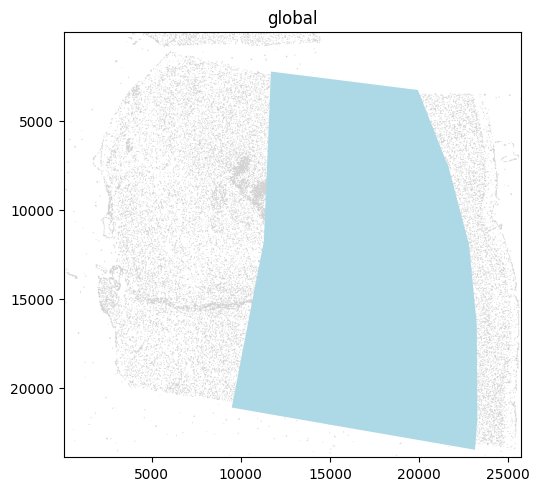

In [6]:
# verify that the ROIs are still there, we know they are but sanity check.
sdata_WA09_GFP_44471_human.pl.render_shapes("cell_boundaries").pl.render_shapes("human_cells", color="lightblue", alpha=0.1).pl.show()

### Make anndata objects and subset to only include cells in human_cells roi

In [7]:
# subset anndata objects and only include cells in the human_cells ROI

# WA09_GFP_44471
adata_WA09_GFP_44471_human = sdata_WA09_GFP_44471_human.tables["table"]
print(adata_WA09_GFP_44471_human)

# Subset your data based on annotation
adata_WA09_GFP_44471_human_roi = adata_WA09_GFP_44471_human[adata_WA09_GFP_44471_human.obs["annotation"] == "human_cells"].copy()
print(adata_WA09_GFP_44471_human_roi)

# WA09_GFP_44480
adata_WA09_GFP_44480_human = sdata_WA09_GFP_44480_human.tables["table"]
print(adata_WA09_GFP_44480_human)

# Subset your data based on annotation
adata_WA09_GFP_44480_human_roi = adata_WA09_GFP_44480_human[adata_WA09_GFP_44480_human.obs["annotation"] == "human_cells"].copy()
print(adata_WA09_GFP_44480_human_roi)


# WA09_39982
adata_WA09_39982_human = sdata_WA09_39982_human.tables["table"]
print(adata_WA09_39982_human)

# Subset your data based on annotation
adata_WA09_39982_human_roi = adata_WA09_39982_human[adata_WA09_39982_human.obs["annotation"] == "human_cells"].copy()
print(adata_WA09_39982_human_roi)

# WA09_40012
adata_WA09_40012_human = sdata_WA09_40012_human.tables["table"]
print(adata_WA09_40012_human)

# Subset your data based on annotation
adata_WA09_40012_human_roi = adata_WA09_40012_human[adata_WA09_40012_human.obs["annotation"] == "human_cells"].copy()
print(adata_WA09_40012_human_roi)


# C27_31900
adata_C27_31900_human = sdata_C27_31900_human.tables["table"]
print(adata_C27_31900_human)

# Subset your data based on annotation
adata_C27_31900_human_roi = adata_C27_31900_human[adata_C27_31900_human.obs["annotation"] == "human_cells"].copy()
print(adata_C27_31900_human_roi)


# C27_33475
adata_C27_33475_human = sdata_C27_33475_human.tables["table"]
print(adata_C27_33475_human)

# Subset your data based on annotation
adata_C27_33475_human_roi = adata_C27_33475_human[adata_C27_33475_human.obs["annotation"] == "human_cells"].copy()
print(adata_C27_33475_human_roi)



AnnData object with n_obs × n_vars = 73790 × 5001
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sample_id', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 39947 × 5001
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sample_id', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
AnnData object with n_obs × n_va

## Concatenate all anndata objects

This first analysis includes all cells in all samples that are within the ROIs drawn in 01_data_read_and_crop.ipynb

In [8]:
# Make sure the obs_names are unique before concatenating
adata_WA09_GFP_44471_human_roi.obs_names_make_unique()
adata_WA09_GFP_44480_human_roi.obs_names_make_unique()
adata_WA09_39982_human_roi.obs_names_make_unique()
adata_WA09_40012_human_roi.obs_names_make_unique()
adata_C27_31900_human_roi.obs_names_make_unique()
adata_C27_33475_human_roi.obs_names_make_unique()

In [9]:
# Create concatenated adata object for all tissue samples
adata_combined = anndata.concat([adata_WA09_GFP_44471_human_roi, adata_WA09_GFP_44480_human_roi, adata_WA09_39982_human_roi, adata_WA09_40012_human_roi, adata_C27_31900_human_roi, adata_C27_33475_human_roi], 
                                axis=0, 
                                label="sample_id", 
                                join = "outer",
                                index_unique="-",
                                keys=["WA09_GFP_44471", "WA09_GFP_44480", "WA09_39982", "WA09_40012", "C27_31900", "C27_33475"])

In [10]:
# Additional checks on the combined object
# First check individual objects
print("Individual datasets:")
print("WA09_GFP_44471:", adata_WA09_GFP_44471_human_roi.shape)
print("WA09_GFP_44480:", adata_WA09_GFP_44480_human_roi.shape)
print("WA09_39982:", adata_WA09_39982_human_roi.shape)
print("WA09_40012:", adata_WA09_40012_human_roi.shape)
print("C27_31900:", adata_C27_31900_human_roi.shape)
print("C27_33475:", adata_C27_33475_human_roi.shape)

# Check gene overlap
genes_1 = set(adata_WA09_GFP_44471_human_roi.var_names)
genes_2 = set(adata_WA09_GFP_44480_human_roi.var_names)
genes_3 = set(adata_WA09_39982_human_roi.var_names)
genes_4 = set(adata_WA09_40012_human_roi.var_names)
genes_5 = set(adata_C27_31900_human_roi.var_names)
genes_6 = set(adata_C27_33475_human_roi.var_names)

print("\nGene overlap:")
print("Genes in all four datasets:", len(genes_1.intersection(genes_2, genes_3, genes_4, genes_5, genes_6)))
print("Unique genes in dataset 1:", len(genes_1.difference(genes_2, genes_3)))
print("Unique genes in dataset 2:", len(genes_2.difference(genes_1, genes_3)))
print("Unique genes in dataset 3:", len(genes_3.difference(genes_1, genes_2)))
print("Unique genes in dataset 4:", len(genes_4.difference(genes_1, genes_2)))
print("Unique genes in dataset 5:", len(genes_5.difference(genes_1, genes_2)))
print("Unique genes in dataset 6:", len(genes_6.difference(genes_1, genes_2)))

# Check combined object
print("\nCombined dataset:")
print("Shape:", adata_combined.shape)
print("Sample distribution:")
print(adata_combined.obs['sample_id'].value_counts())

# Check if key metadata columns are preserved
print("\nMetadata columns preserved:")
print("In original:", list(adata_WA09_GFP_44471_human_roi.obs.columns))
print("In combined:", list(adata_combined.obs.columns))

# Check if spatial coordinates are preserved
print("\nSpatial coordinates preserved:")
print("Original spatial keys:", list(adata_WA09_GFP_44471_human_roi.obsm.keys()))
print("Combined spatial keys:", list(adata_combined.obsm.keys()))

Individual datasets:
WA09_GFP_44471: (39947, 5001)
WA09_GFP_44480: (22880, 5001)
WA09_39982: (31405, 5001)
WA09_40012: (33000, 5001)
C27_31900: (24543, 5001)
C27_33475: (23109, 5001)

Gene overlap:
Genes in all four datasets: 5001
Unique genes in dataset 1: 0
Unique genes in dataset 2: 0
Unique genes in dataset 3: 0
Unique genes in dataset 4: 0
Unique genes in dataset 5: 0
Unique genes in dataset 6: 0

Combined dataset:
Shape: (174884, 5001)
Sample distribution:
sample_id
WA09_GFP_44471    39947
WA09_40012        33000
WA09_39982        31405
C27_31900         24543
C27_33475         23109
WA09_GFP_44480    22880
Name: count, dtype: int64

Metadata columns preserved:
In original: ['cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sampl

In [11]:
# check the spatial coordinates, are they in pixels?
print(adata_combined.obsm["spatial"])

[[3091.58154297  755.49005127]
 [3111.68676758  768.70184326]
 [3104.26806641  770.14178467]
 ...
 [4534.62841797 2721.82324219]
 [4469.63476562 2639.17919922]
 [4461.45117188 2639.98999023]]


### Quality check

In [12]:
sc.pp.calculate_qc_metrics(adata_combined, percent_top=(10, 20, 50, 150), inplace=True)

In [13]:
cprobes = (
    adata_combined.obs["control_probe_counts"].sum() / adata_combined.obs["total_counts"].sum() * 100
)
cwords = (
    adata_combined.obs["control_codeword_counts"].sum() / adata_combined.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.002044418033140169
Negative decoding count % : 0.0004119349768267505


<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

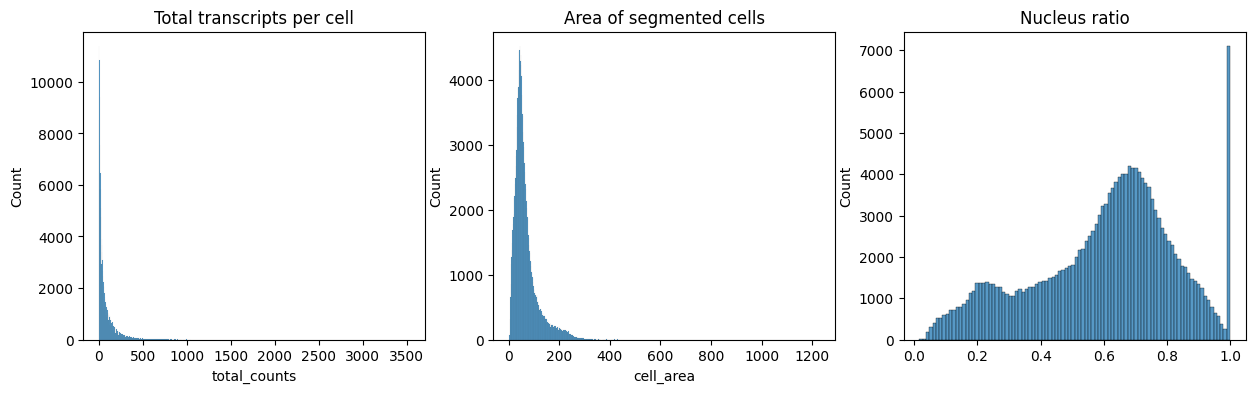

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata_combined.obs["total_counts"],
    kde=False,
    ax=axs[0],
)


axs[1].set_title("Area of segmented cells")
sns.histplot(
    adata_combined.obs["cell_area"],
    kde=False,
    ax=axs[1],
)

axs[2].set_title("Nucleus ratio")
sns.histplot(
    adata_combined.obs["nucleus_area"] / adata_combined.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

In [15]:
# Save the raw counts before normalizing
# without a copy statement here, the raw data will be overwritten by the normalized data

# Freeze the state in raw
adata_combined.raw = adata_combined.copy()
# Preserve the raw counts in a layer
adata_combined.layers['raw'] = adata_combined.X.copy()
adata_combined

AnnData object with n_obs × n_vars = 174884 × 5001
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sample_id', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'
    layers: 'raw'

In [16]:
# Export the raw metadata before filtering
# Export comprehensive metadata including spatial coordinates and UMAP embeddings
# Combine all observation metadata with spatial coordinates and UMAP embeddings
comprehensive_metadata = adata_combined.obs.copy()

# Add the current cell names (index) as a column
comprehensive_metadata['current_cell_id'] = adata_combined.obs.index

# Add spatial coordinates
comprehensive_metadata['spatial_x'] = adata_combined.obsm['spatial'][:, 0]
comprehensive_metadata['spatial_y'] = adata_combined.obsm['spatial'][:, 1]

# Create output directory if it doesn't exist
output_dir = FILES_FOR_R_DIR
os.makedirs(output_dir, exist_ok=True)

# Save comprehensive metadata to CSV
output_filename = f'{output_dir}/adata_combined_pre_filtering_comprehensive_cell_metadata.csv'
comprehensive_metadata.to_csv(output_filename, index=False)

print(f"Comprehensive metadata exported to: {output_filename}")
print(f"Total cells: {len(comprehensive_metadata)}")
print(f"Total columns: {len(comprehensive_metadata.columns)}")
print(f"Columns included:")
print(comprehensive_metadata.columns.tolist())
print(f"\nFirst few rows:")
print(comprehensive_metadata.head())

Comprehensive metadata exported to: /Users/haichelm/Documents/Goldman_Lab/Composition_Paper/composition_analysis_github/outputs/files_for_R/adata_combined_pre_filtering_comprehensive_cell_metadata.csv
Total cells: 174884
Total columns: 28
Columns included:
['cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sample_id', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'current_cell_id', 'spatial_x', 'spatial_y']

First few rows:
                              cell_id  transcript_counts  \
cell_id                                                    
adnaidpo-1-WA09_GFP_44471  adnaidpo-1  

In [17]:
# filter out low quality cells and high outlier cells
sc.pp.filter_cells(adata_combined, min_genes=50)
sc.pp.filter_cells(adata_combined, max_genes=2000)

# how many cells are left after filtering?
print(adata_combined)

AnnData object with n_obs × n_vars = 60295 × 5001
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sample_id', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'
    layers: 'raw'


<Axes: xlabel='total_counts', ylabel='Count'>

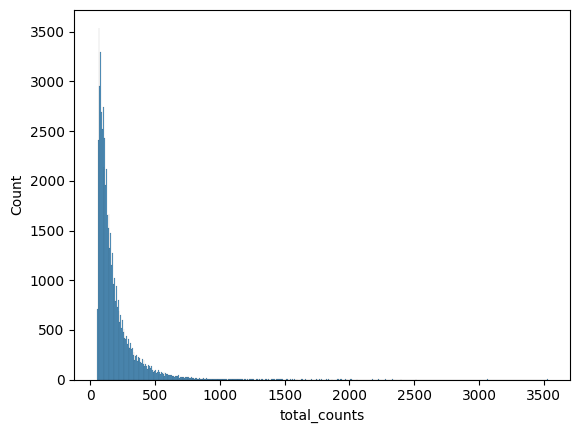

In [18]:
# Visualize histogram of total counts again to see how filtering affected things
sns.histplot(adata_combined.obs["total_counts"])

### Incorporate human Xenium probe specificity information

In [19]:
# Read the human probe specificity data
human_probes = pd.read_csv(f'{INPUT_DIR}/probes/human_probe_specificity_metrics.csv')

# Create dictionaries for mapping gene names to specificity scores
human2human_dict = dict(zip(human_probes['queryID'], human_probes['mean_human2human_specificity']))
human2mouse_dict = dict(zip(human_probes['queryID'], human_probes['mean_human2mouse']))

# Get the list of genes in your anndata object that match with the probe specificity data
common_genes = [gene for gene in adata_combined.var_names if gene in human_probes['queryID'].values]

# Add the specificity scores as new columns in .var
adata_combined.var['human2human_specificity'] = pd.Series(
    [human2human_dict.get(gene, np.nan) for gene in adata_combined.var_names],
    index=adata_combined.var_names
)

adata_combined.var['human2mouse_specificity'] = pd.Series(
    [human2mouse_dict.get(gene, np.nan) for gene in adata_combined.var_names],
    index=adata_combined.var_names
)

# Print some basic statistics about the added metrics
print(f"Total number of genes: {adata_combined.shape[1]}")
print(f"Number of genes with specificity data: {len(common_genes)}")
print(f"Number of genes without specificity data: {adata_combined.shape[1] - len(common_genes)}")

print("\nSummary of human2human specificity scores:")
print(adata_combined.var['human2human_specificity'].describe())
print("\nSummary of human2mouse specificity scores:")
print(adata_combined.var['human2mouse_specificity'].describe())

Total number of genes: 5001
Number of genes with specificity data: 5001
Number of genes without specificity data: 0

Summary of human2human specificity scores:
count    5001.000000
mean       30.907131
std         2.709850
min         0.000000
25%        31.333333
50%        32.000000
75%        32.000000
max        32.000000
Name: human2human_specificity, dtype: float64

Summary of human2mouse specificity scores:
count    5001.000000
mean        6.223514
std         6.797315
min         0.000000
25%         0.000000
50%         6.666667
75%        10.000000
max        32.000000
Name: human2mouse_specificity, dtype: float64


### Normalization and dimensionality reduction

In [20]:
# Show summary of raw data
print("Raw data summary:")
print(adata_combined.raw.X)

# Show first few entries
print("\nFirst few entries in raw data:")
print(adata_combined.raw.X[:5, :10])

Raw data summary:
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7542734 stored elements and shape (60295, 5001)>
  Coords	Values
  (0, 36)	1.0
  (0, 87)	2.0
  (0, 88)	1.0
  (0, 206)	1.0
  (0, 207)	1.0
  (0, 268)	1.0
  (0, 302)	2.0
  (0, 319)	1.0
  (0, 320)	2.0
  (0, 353)	1.0
  (0, 368)	1.0
  (0, 375)	1.0
  (0, 429)	1.0
  (0, 434)	1.0
  (0, 493)	1.0
  (0, 545)	1.0
  (0, 641)	1.0
  (0, 722)	2.0
  (0, 734)	1.0
  (0, 744)	1.0
  (0, 816)	1.0
  (0, 885)	1.0
  (0, 886)	1.0
  (0, 887)	3.0
  (0, 957)	1.0
  :	:
  (60294, 2908)	1.0
  (60294, 2940)	1.0
  (60294, 3049)	1.0
  (60294, 3126)	1.0
  (60294, 3352)	1.0
  (60294, 3435)	1.0
  (60294, 3719)	1.0
  (60294, 3796)	1.0
  (60294, 3830)	1.0
  (60294, 3934)	3.0
  (60294, 4105)	1.0
  (60294, 4138)	2.0
  (60294, 4177)	1.0
  (60294, 4196)	1.0
  (60294, 4242)	1.0
  (60294, 4346)	1.0
  (60294, 4355)	1.0
  (60294, 4394)	1.0
  (60294, 4491)	1.0
  (60294, 4603)	1.0
  (60294, 4743)	1.0
  (60294, 4846)	1.0
  (60294, 4901)	1.0
  (60294, 4906)	2

In [21]:
# Normalize to median total counts
sc.pp.normalize_total(adata_combined, inplace=True)
# Logarithmize the data
sc.pp.log1p(adata_combined)

In [22]:
# Show summary of normalized data to confirm the counts are now normalized
print("Normalized data summary:")
print(adata_combined.X)

# Show first few entries
print("\nFirst few entries in normalized data:")
print(adata_combined.X[:5, :10])

Normalized data summary:
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7542734 stored elements and shape (60295, 5001)>
  Coords	Values
  (0, 36)	0.44336435198783875
  (0, 87)	0.7494707107543945
  (0, 88)	0.44336435198783875
  (0, 206)	0.44336435198783875
  (0, 207)	0.44336435198783875
  (0, 268)	0.44336435198783875
  (0, 302)	0.7494707107543945
  (0, 319)	0.44336435198783875
  (0, 320)	0.7494707107543945
  (0, 353)	0.44336435198783875
  (0, 368)	0.44336435198783875
  (0, 375)	0.44336435198783875
  (0, 429)	0.44336435198783875
  (0, 434)	0.44336435198783875
  (0, 493)	0.44336435198783875
  (0, 545)	0.44336435198783875
  (0, 641)	0.44336435198783875
  (0, 722)	0.7494707107543945
  (0, 734)	0.44336435198783875
  (0, 744)	0.44336435198783875
  (0, 816)	0.44336435198783875
  (0, 885)	0.44336435198783875
  (0, 886)	0.44336435198783875
  (0, 887)	0.9835080504417419
  (0, 957)	0.44336435198783875
  :	:
  (60294, 2908)	1.0316015481948853
  (60294, 2940)	1.0316015481948853
  (60

In [23]:
# save normalized counts in a layer for easier plotting
adata_combined.layers["normalized"] = adata_combined.X.copy()
print(adata_combined)

AnnData object with n_obs × n_vars = 60295 × 5001
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sample_id', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'human2human_specificity', 'human2mouse_specificity'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'raw', 'normalized'


Number of highly variable genes: 410


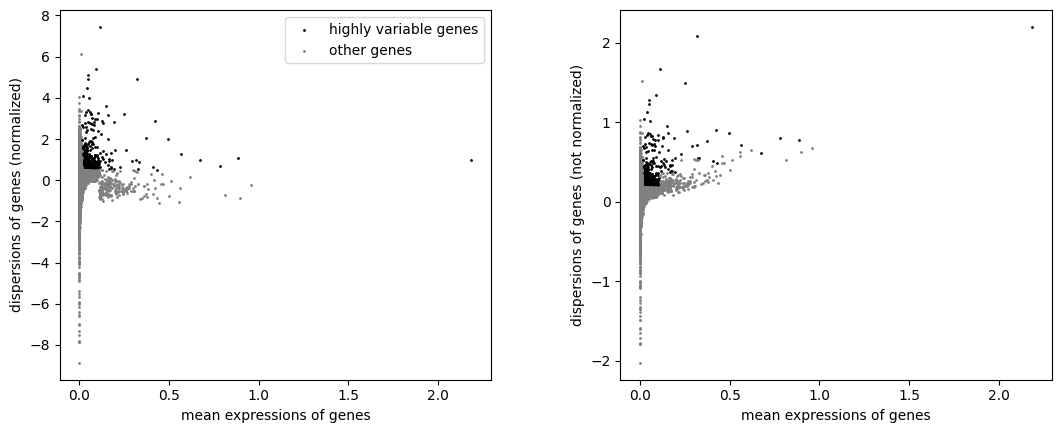

In [24]:
# Identify highly variable features

# default method is seurat, I have also tried updating to seurat_v3 following this: https://www.medrxiv.org/content/10.1101/2025.02.09.25321567v2.full
# more info here: https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.highly_variable_genes.html
#sc.pp.highly_variable_genes(adata, layer = "raw", flavor = "seurat_v3")
# I ultimately found that the seurat_v3 method gave us more genes (2000) as the default, and that cell typing was harder with this method.

# to use default seurat method:
sc.pp.highly_variable_genes(adata_combined, flavor = "seurat")

# Check number of genes and plot
n_genes = sum(adata_combined.var.highly_variable)
print(f"Number of highly variable genes: {n_genes}")
sc.pl.highly_variable_genes(adata_combined)


In [ ]:
# Dimensionality reduction 
sc.tl.pca(adata_combined)

sc.pp.neighbors(adata_combined)

sc.tl.umap(adata_combined, random_state = 42)

sc.tl.leiden(adata_combined, random_state = 42, key_added="leiden_res0_1",resolution=0.1)
sc.tl.leiden(adata_combined, random_state = 42, key_added="leiden_res0_5",resolution=0.5)
sc.tl.leiden(adata_combined, random_state = 42, key_added="leiden_res0_75",resolution=0.75)
sc.tl.leiden(adata_combined, random_state = 42, key_added="leiden_res1",resolution=1.0)

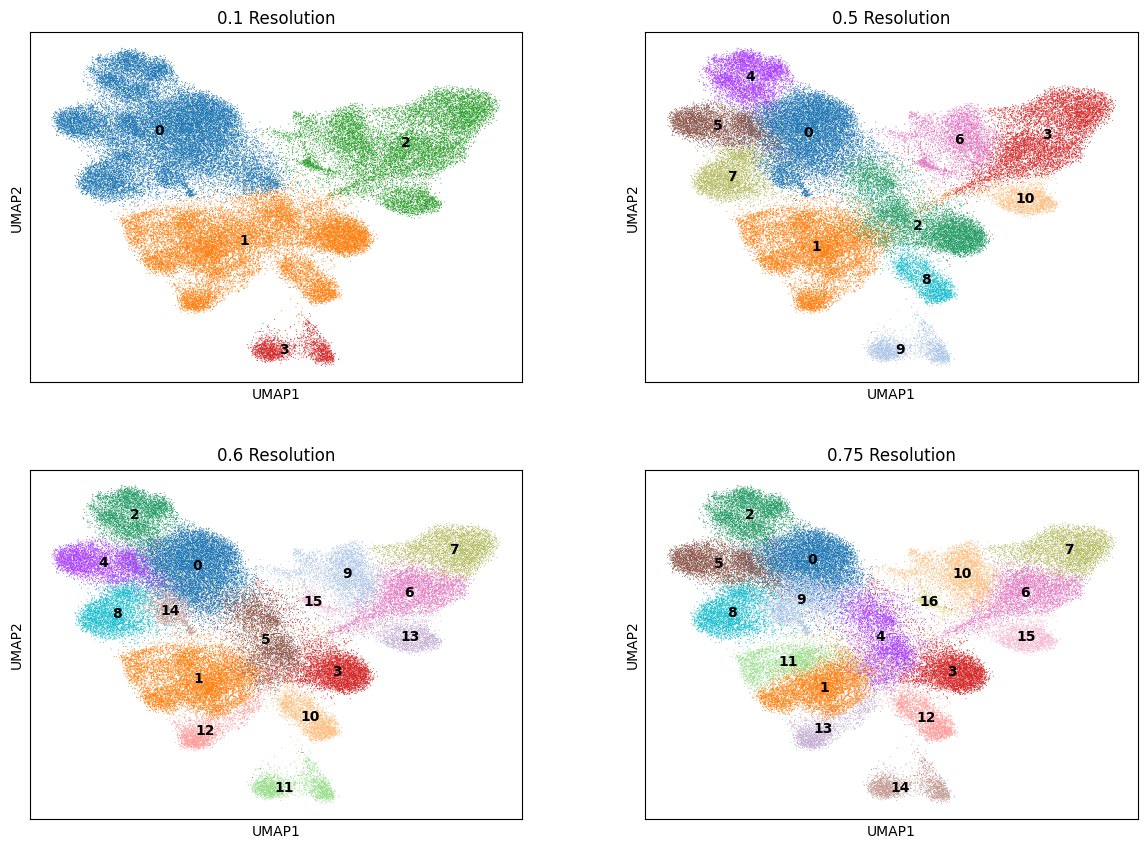

In [26]:
# Plot UMAPs with different resolutions
sc.pl.umap(
    adata_combined,
    color=["leiden_res0_1", "leiden_res0_5", "leiden_res0_75", "leiden_res1"],
    ncols=2,
    legend_loc = "on data",
    title = ["0.1 Resolution", "0.5 Resolution", "0.6 Resolution", "0.75 Resolution", "1 Resolution"]
)

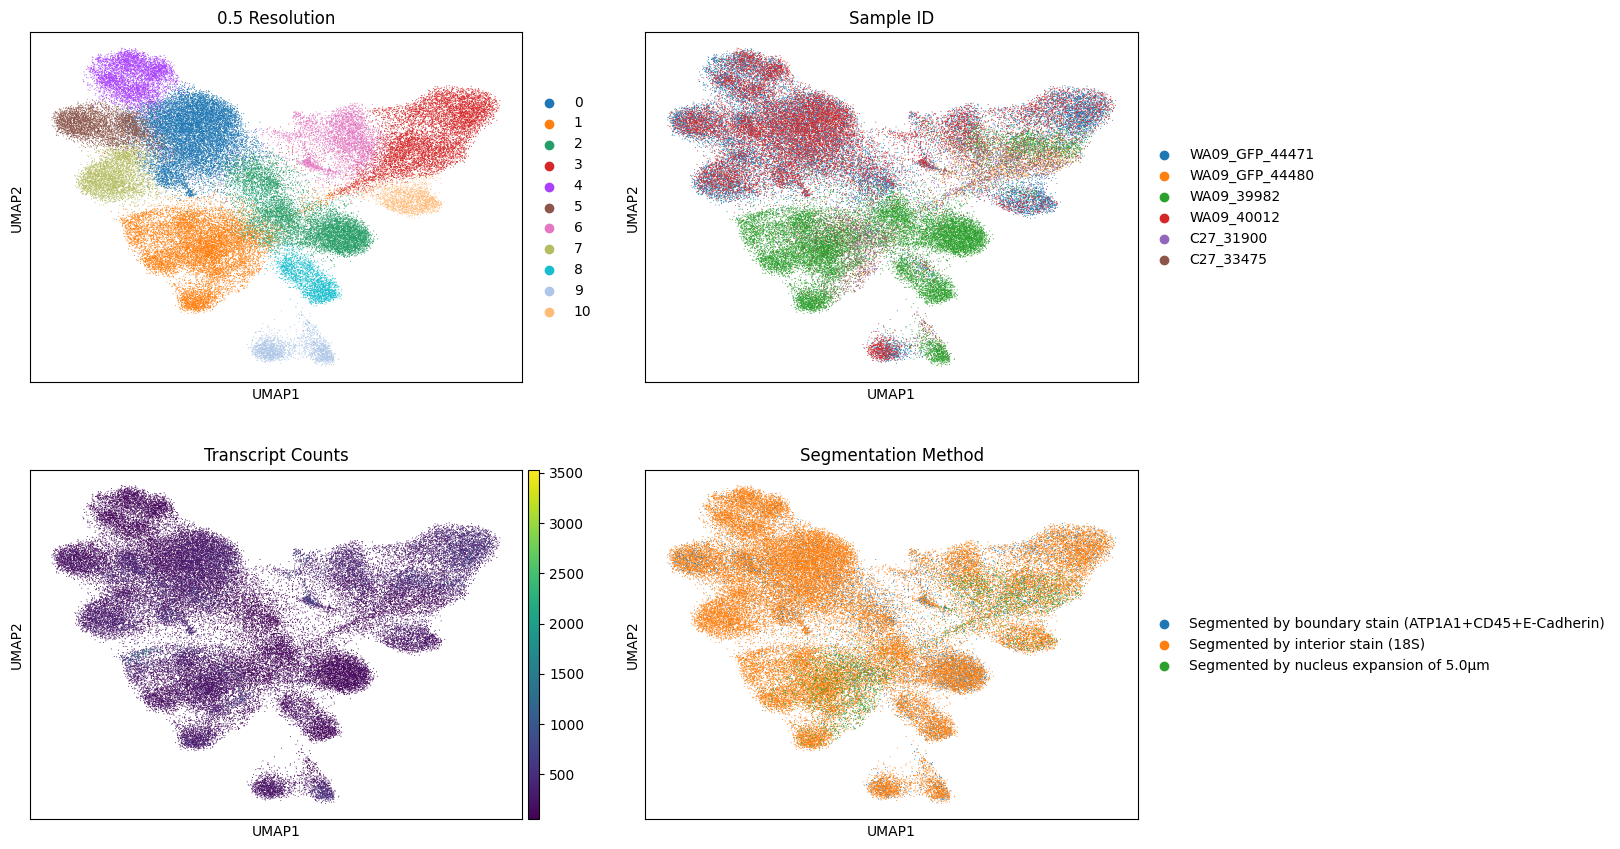

In [27]:
# Re-assess quality control and cell filtering by visualizing other features of the data 
sc.pl.umap(
    adata_combined,
    color=["leiden_res0_5", "sample_id", "transcript_counts", "segmentation_method"],
    ncols=2,
    title = ["0.5 Resolution", "Sample ID", "Transcript Counts", "Segmentation Method"]
)

### Assess human probe specificity score in context of UMAPs

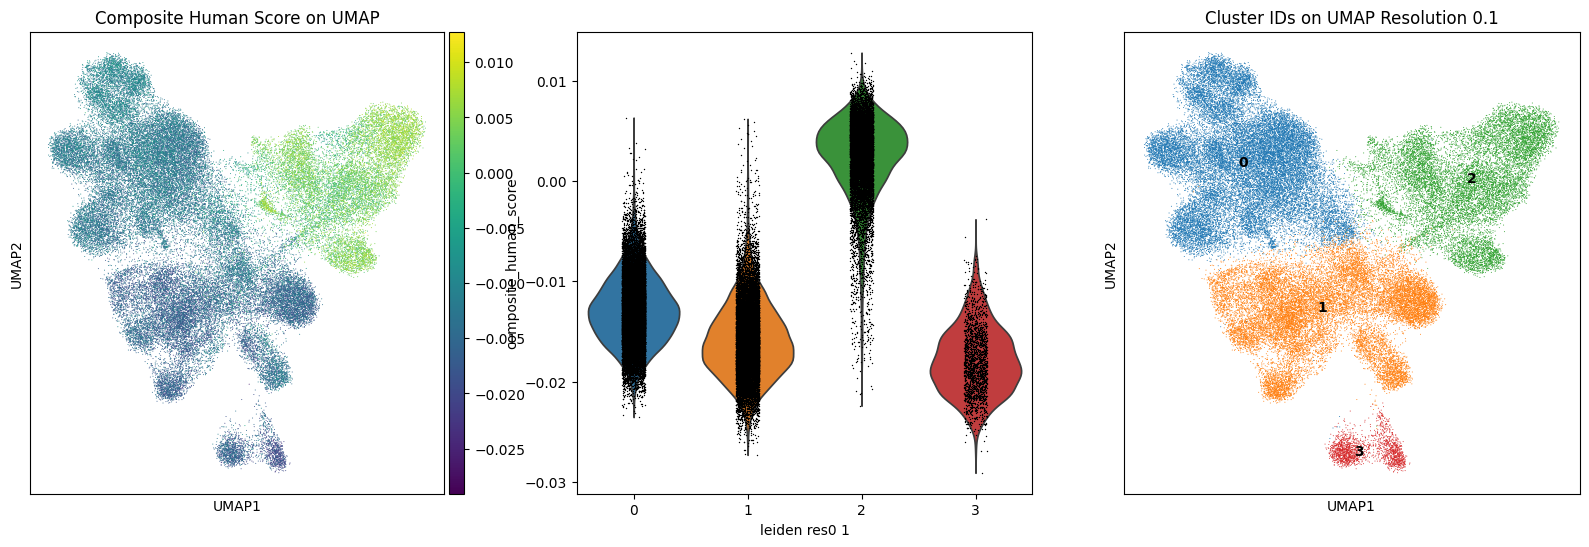

<Figure size 640x480 with 0 Axes>

In [28]:
# Create a composite probe score 
# 1. Expression of perfectly human-specific genes
perfect_human = adata_combined.var['human2human_specificity'] == 32
perfect_expr = adata_combined[:, perfect_human].X.mean(axis=1)

# 2. Penalize expression of highly cross-reactive genes
cross_reactive = adata_combined.var['human2mouse_specificity'] >= 15
cross_expr = adata_combined[:, cross_reactive].X.mean(axis=1)

# 3. Calculate composite score
# Essentially: Composite Score = (Mean expression of perfect human genes) - 0.5 × (Mean expression of cross-reactive genes)
# higher positive score = more human-specific expression
# lower negative score = more mouse-like expression pattern (cross-reactive)
composite_score = perfect_expr - (0.5 * cross_expr)  # Adjust weight (0.5) as needed
adata_combined.obs['composite_human_score'] = composite_score

# Visualize scores
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# UMAP colored by score
sc.pl.umap(adata_combined, color=['composite_human_score'], ax=ax1, show=False)
ax1.set_title('Composite Human Score on UMAP')

# UMAP colored by cluster IDs
sc.pl.umap(adata_combined, color=['leiden_res0_1'], ax=ax3, legend_loc='on data', show=False)
ax3.set_title('Cluster IDs on UMAP Resolution 0.1')

# Violin plot by cluster
sc.pl.violin(adata_combined, 'composite_human_score', groupby='leiden_res0_1', ax=ax2)
ax2.set_title('Score Distribution by Cluster Resolution 0.1')

plt.tight_layout()
plt.show()

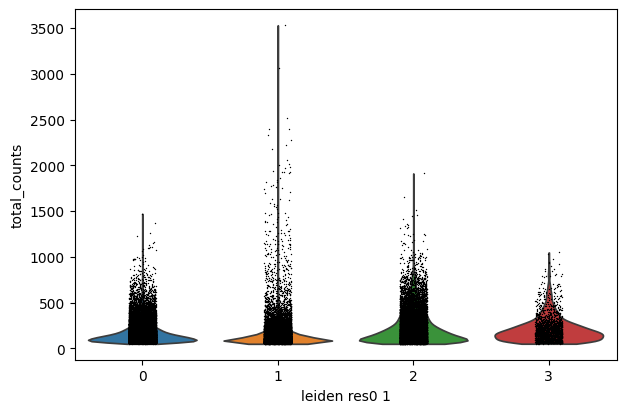

In [29]:
#plot violin plot of total counts by cluster
sc.pl.violin(adata_combined, 'total_counts', groupby='leiden_res0_1')

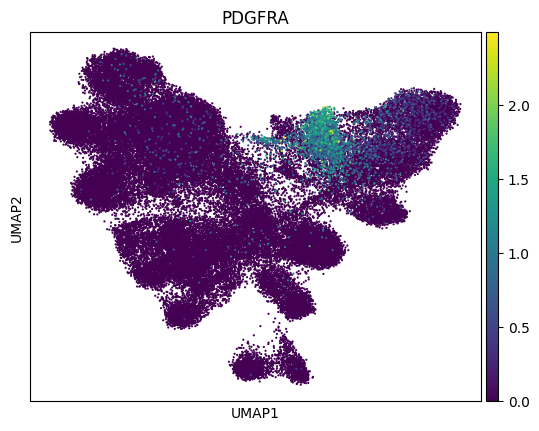

In [30]:
# Visualize human-specific markers (PDGFRA) on the UMAP
sc.pl.umap(
    adata_combined,
    color=["PDGFRA"],
    ncols=1,
    legend_loc = "on data",
    title = ["PDGFRA"],
    size = 10,
    layer = 'normalized'
)

In combination with the probe specificity score, it looks like the top-right cluster (cluster 2 in resolution = 0.1) contains our human cells (and likely some mouse cells too)

In [31]:
# Save adata object before moving on to next step
# Rename the 'cell_id' column to avoid conflict with the index
# This keeps the informative concatenated index while preserving the original cell_id data
adata_combined.obs = adata_combined.obs.rename(columns={'cell_id': 'cell_id_original'})

In [32]:
# Now write the file 
adata_combined.write_h5ad(f'{ANNDATA_DIR}/adata_combined.h5ad')

In [33]:
# Export comprehensive metadata including spatial coordinates and UMAP embeddings
# Combine all observation metadata with spatial coordinates and UMAP embeddings
comprehensive_metadata = adata_combined.obs.copy()

# Add the current cell names (index) as a column
comprehensive_metadata['current_cell_id'] = adata_combined.obs.index

# Add spatial coordinates
comprehensive_metadata['spatial_x'] = adata_combined.obsm['spatial'][:, 0]
comprehensive_metadata['spatial_y'] = adata_combined.obsm['spatial'][:, 1]

# Add UMAP embeddings
comprehensive_metadata['UMAP_1'] = adata_combined.obsm['X_umap'][:, 0]
comprehensive_metadata['UMAP_2'] = adata_combined.obsm['X_umap'][:, 1]

# Add PCA coordinates if available
if 'X_pca' in adata_combined.obsm:
    for i in range(min(5, adata_combined.obsm['X_pca'].shape[1])):
        comprehensive_metadata[f'PC{i+1}'] = adata_combined.obsm['X_pca'][:, i]

# Create output directory if it doesn't exist
output_dir = FILES_FOR_R_DIR
os.makedirs(output_dir, exist_ok=True)

# Save comprehensive metadata to CSV
output_filename = f'{output_dir}/adata_combined_comprehensive_cell_metadata.csv'
comprehensive_metadata.to_csv(output_filename, index=False)

print(f"Comprehensive metadata exported to: {output_filename}")
print(f"Total cells: {len(comprehensive_metadata)}")
print(f"Total columns: {len(comprehensive_metadata.columns)}")
print(f"Columns included:")
print(comprehensive_metadata.columns.tolist())
print(f"\nFirst few rows:")
print(comprehensive_metadata.head())


Comprehensive metadata exported to: /Users/haichelm/Documents/Goldman_Lab/Composition_Paper/composition_analysis_github/outputs/files_for_R/adata_combined_comprehensive_cell_metadata.csv
Total cells: 60295
Total columns: 41
Columns included:
['cell_id_original', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sample_id', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_genes', 'leiden_res0_1', 'leiden_res0_5', 'leiden_res0_75', 'leiden_res1', 'composite_human_score', 'current_cell_id', 'spatial_x', 'spatial_y', 'UMAP_1', 'UMAP_2', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5']

First few rows:
       

## Subset out human cell-containing cells and re-cluster to type human cells

In [34]:
# subset out cluster 2 cells, re-cluster and visualize
adata_combined_cluster2 = adata_combined[adata_combined.obs['leiden_res0_1'] == '2'].copy()
print(adata_combined_cluster2)

AnnData object with n_obs × n_vars = 13147 × 5001
    obs: 'cell_id_original', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sample_id', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_genes', 'leiden_res0_1', 'leiden_res0_5', 'leiden_res0_75', 'leiden_res1', 'composite_human_score'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'human2human_specificity', 'human2mouse_specificity', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_res

Number of highly variable genes: 498


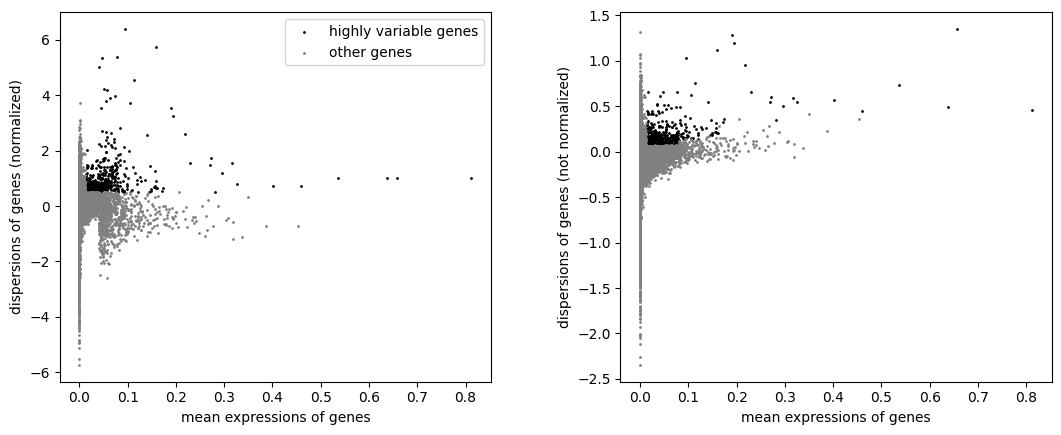

In [35]:
# re-find variable features
# to use default seurat method:
sc.pp.highly_variable_genes(adata_combined_cluster2, flavor = "seurat")

# Check number of genes and plot
n_genes = sum(adata_combined_cluster2.var.highly_variable)
print(f"Number of highly variable genes: {n_genes}")
sc.pl.highly_variable_genes(adata_combined_cluster2)

In [36]:
# Dimensionality reduction 
sc.tl.pca(adata_combined_cluster2)

sc.pp.neighbors(adata_combined_cluster2)

sc.tl.umap(adata_combined_cluster2, random_state = 42)

sc.tl.leiden(adata_combined_cluster2, random_state = 42, key_added="leiden_cluster2_res0_1",resolution=0.1)
sc.tl.leiden(adata_combined_cluster2, random_state = 42, key_added="leiden_cluster2_res0_5",resolution=0.5)
sc.tl.leiden(adata_combined_cluster2, random_state = 42, key_added="leiden_cluster2_res0_75",resolution=0.75)
sc.tl.leiden(adata_combined_cluster2, random_state = 42, key_added="leiden_cluster2_res1",resolution=1.0)

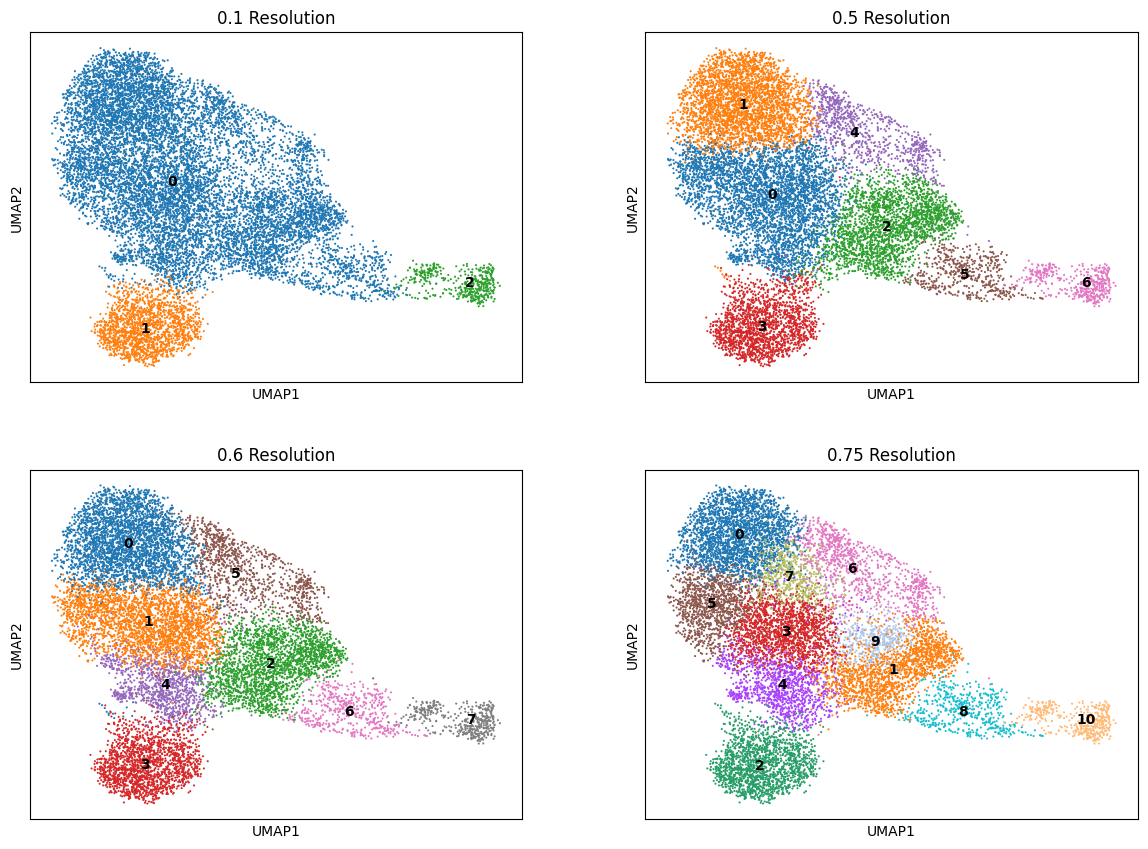

In [37]:
# Plot UMAPs with different resolutions
sc.pl.umap(
    adata_combined_cluster2,
    color=["leiden_cluster2_res0_1", "leiden_cluster2_res0_5", "leiden_cluster2_res0_75", "leiden_cluster2_res1"],
    ncols=2,
    legend_loc = "on data",
    title = ["0.1 Resolution", "0.5 Resolution", "0.6 Resolution", "0.75 Resolution", "1 Resolution"]
)

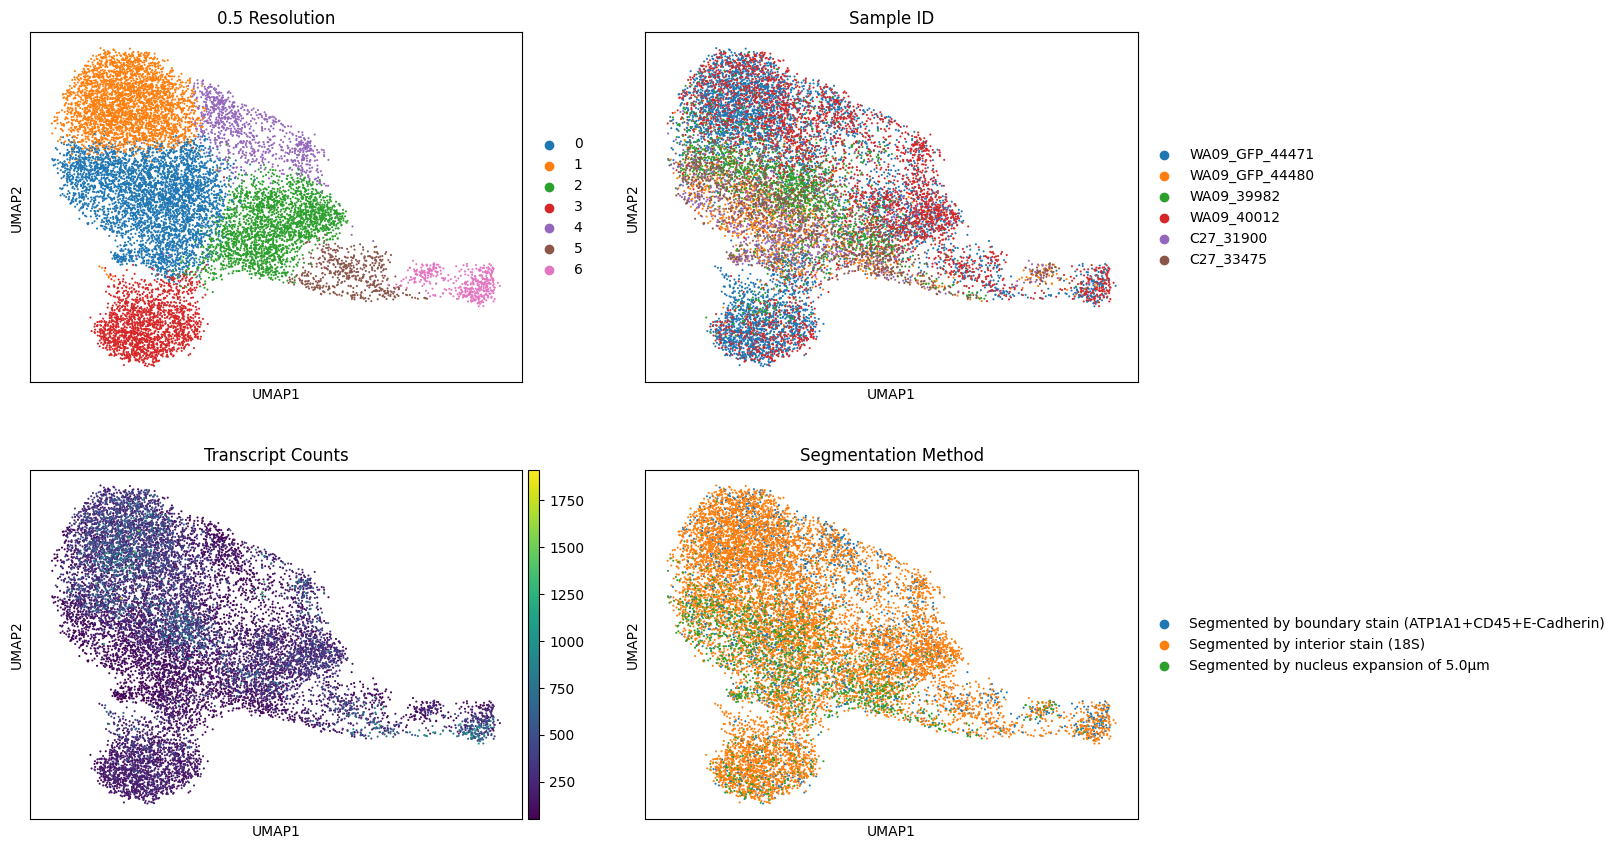

In [38]:
# Re-assess quality control and cell filtering by visualizing other features of the data 
sc.pl.umap(
    adata_combined_cluster2,
    color=["leiden_cluster2_res0_5", "sample_id", "transcript_counts", "segmentation_method"],
    ncols=2,
    title = ["0.5 Resolution", "Sample ID", "Transcript Counts", "Segmentation Method"]
)

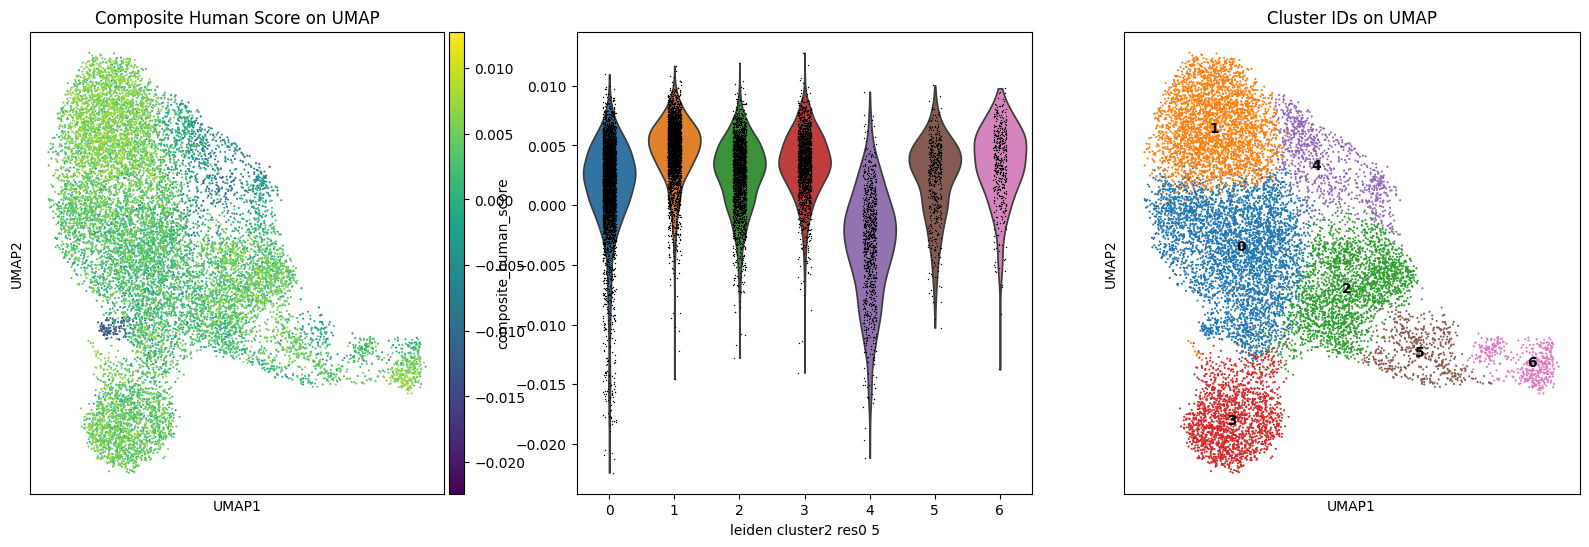

<Figure size 640x480 with 0 Axes>

In [39]:
# Visualize human probe specificity scores
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# UMAP colored by score
sc.pl.umap(adata_combined_cluster2, color=['composite_human_score'], ax=ax1, show=False)
ax1.set_title('Composite Human Score on UMAP')

# UMAP colored by cluster IDs
sc.pl.umap(adata_combined_cluster2, color=['leiden_cluster2_res0_5'], ax=ax3, legend_loc='on data', show=False)
ax3.set_title('Cluster IDs on UMAP')

# Violin plot by cluster
sc.pl.violin(adata_combined_cluster2, 'composite_human_score', groupby='leiden_cluster2_res0_5', ax=ax2)
ax2.set_title('Score Distribution by Cluster')

plt.tight_layout()
plt.show()

### Plot violins of genes of interest

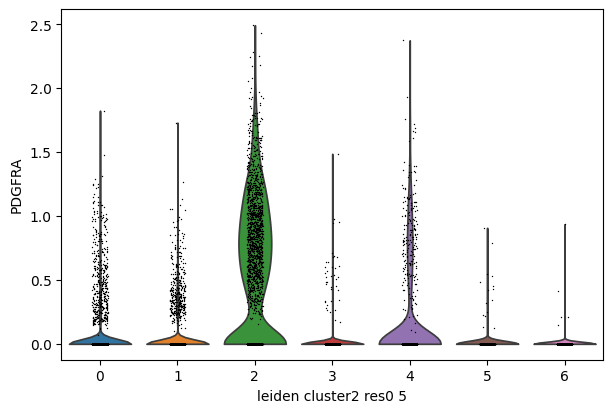

In [40]:
#plot violin plot of normalized counts of PDGFRA by cluster
sc.pl.violin(adata_combined_cluster2, ["PDGFRA"], groupby='leiden_cluster2_res0_5', layer = 'normalized', use_raw = False)


In [ ]:
#plot violin plot of normalized counts of POU5F1 by cluster
sc.pl.violin(adata_combined_cluster2, ["POU5F1"], groupby='leiden_cluster2_res0_5', layer = 'normalized', use_raw = False)

In [ ]:
#plot violin plot of normalized counts of LIN28A by cluster
sc.pl.violin(adata_combined_cluster2, ["LIN28A"], groupby='leiden_cluster2_res0_5', layer = 'normalized', use_raw = False)

In [ ]:
#plot violin plot of receptors of interest

sc.pl.violin(adata_combined_cluster2, ["CD82","CA10","ERBB3","LRP1","CCND1"], groupby='cell_type', layer = 'normalized', use_raw = False)

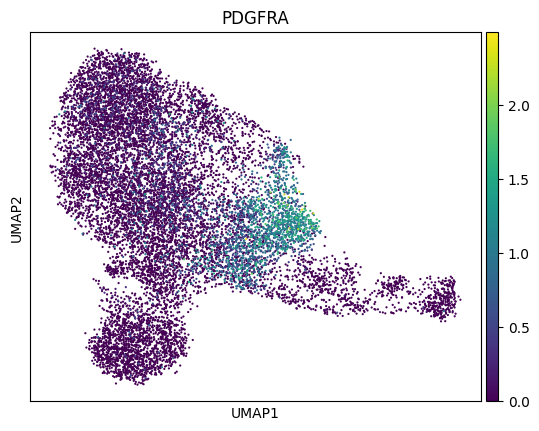

In [41]:
# Visualize some human-specific genes (PDGFRA) on the UMAP
sc.pl.umap(
    adata_combined_cluster2,
    color=["PDGFRA"],
    ncols=1,
    legend_loc = "on data",
    title = ["PDGFRA"],
    size = 10,
    layer = 'normalized'
)

In [42]:
# visualize number of cells per sample_id and cluster
contingency_table = pd.crosstab(adata_combined_cluster2.obs['sample_id'], adata_combined_cluster2.obs['leiden_cluster2_res0_5'])
contingency_table

leiden_cluster2_res0_5,0,1,2,3,4,5,6
sample_id,,,,,,,
WA09_GFP_44471,526,1960,646,1298,375,178,163
WA09_GFP_44480,887,35,221,24,8,31,56
WA09_39982,1127,172,303,84,62,35,1
WA09_40012,270,922,753,375,451,199,150
C27_31900,539,26,147,7,8,18,31
C27_33475,657,30,272,2,5,50,43


### Cell typing

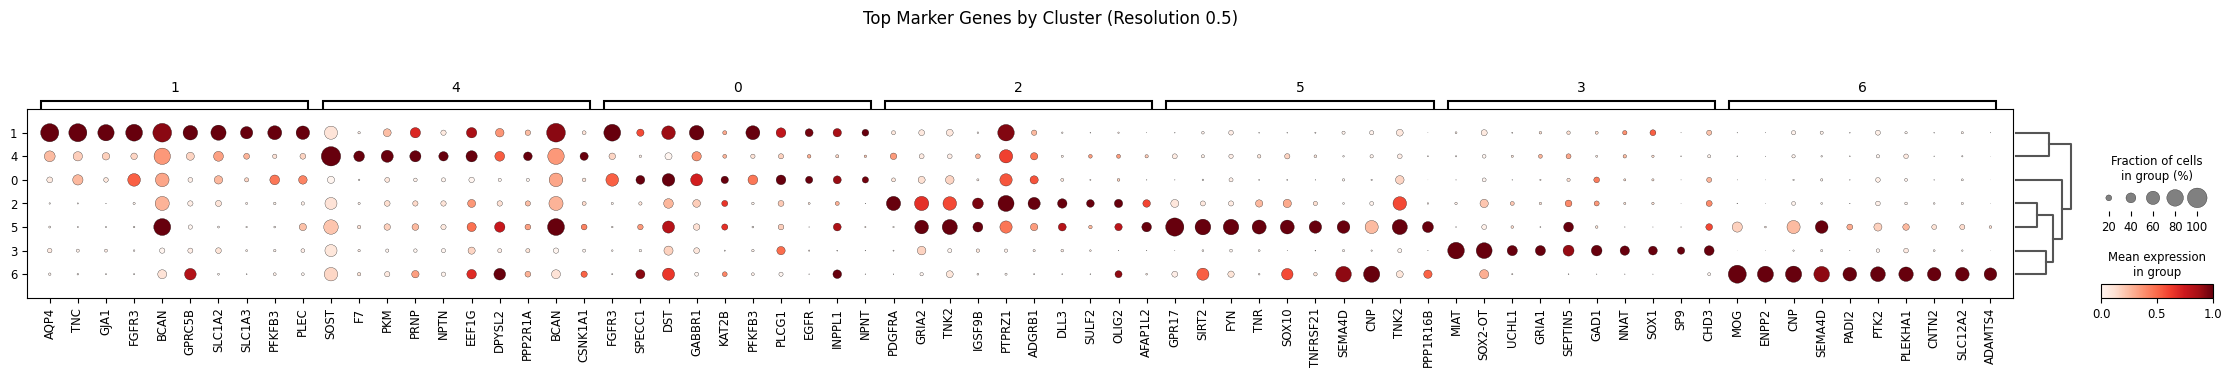

In [43]:
# Visualize marker genes for each cluster
sc.tl.rank_genes_groups(adata_combined_cluster2, groupby='leiden_cluster2_res0_5', method='wilcoxon', layer = 'normalized', use_raw = False)

# Create visualizations of the marker genes
# Dotplot showing top markers for each cluster
sc.pl.rank_genes_groups_dotplot(
    adata_combined_cluster2, 
    groupby='leiden_cluster2_res0_5', 
    n_genes=10,  # Show top 10 genes per cluster
    standard_scale='var',
    title='Top Marker Genes by Cluster (Resolution 0.5)'
)


In [44]:
# Compare cluster 1 to cluster 0
sc.tl.rank_genes_groups(adata_combined_cluster2, 'leiden_cluster2_res0_5', groups=['0'], reference='1', method='wilcoxon', key_added='0vs1', use_raw=False)
sc.tl.rank_genes_groups(adata_combined_cluster2, 'leiden_cluster2_res0_5', groups=['1'], reference='0', method='wilcoxon', key_added='1vs0', use_raw=False)

Plotting sample: WA09_GFP_44471
Number of cells: 5146
Plotting sample: WA09_GFP_44480
Number of cells: 1262
Plotting sample: WA09_39982
Number of cells: 1784
Plotting sample: WA09_40012
Number of cells: 3120
Plotting sample: C27_31900
Number of cells: 776
Plotting sample: C27_33475
Number of cells: 1059


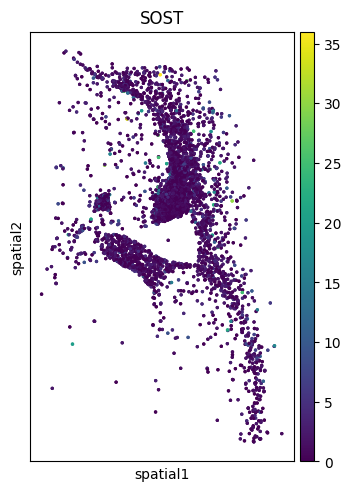

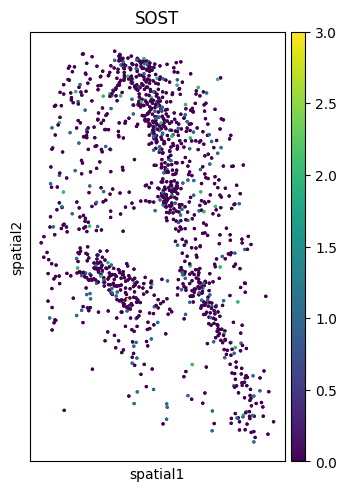

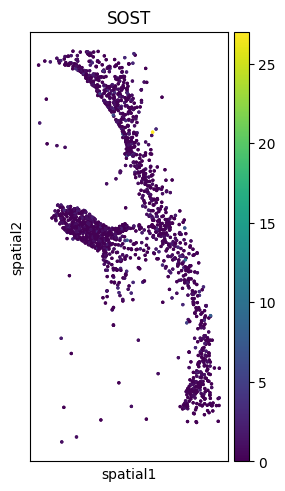

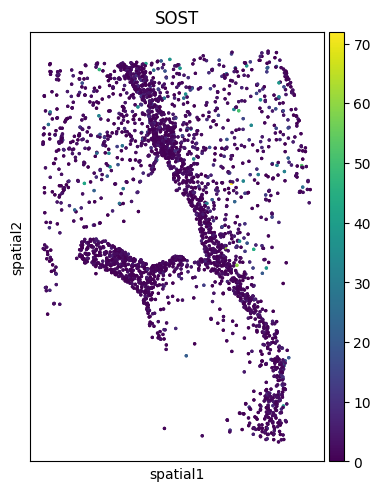

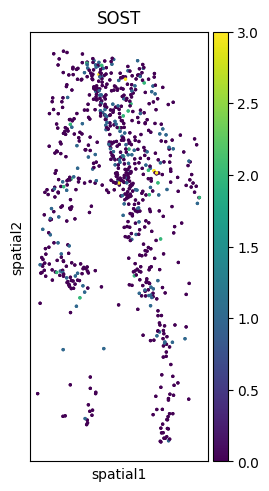

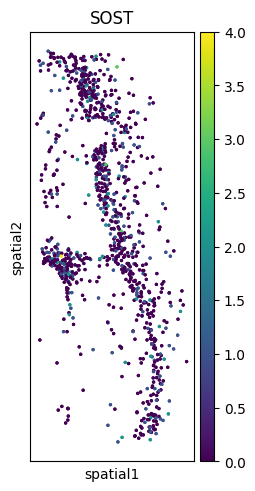

In [45]:
# visualize markers of 'mousey' clusters in space.
# Get unique sample IDs
sample_ids = adata_combined_cluster2.obs['sample_id'].unique()

# Create plots for each sample
for sample_id in sample_ids:
    # Subset data for this sample
    sample_data = adata_combined_cluster2[adata_combined_cluster2.obs['sample_id'] == sample_id].copy()
    
    print(f"Plotting sample: {sample_id}")
    print(f"Number of cells: {len(sample_data)}")
    
    # Create spatial scatter plot
    sq.pl.spatial_scatter(
        sample_data,
        library_id="spatial",
        shape=None,
        color=["SOST"],  # or whatever cell type column you want
        wspace=0.4,
        size=8
    )

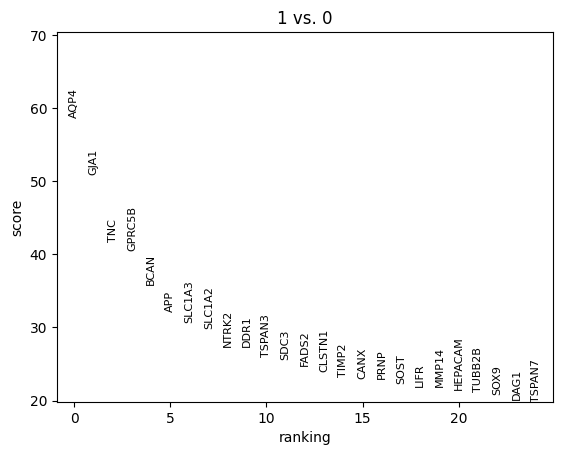

In [46]:
# View results
sc.pl.rank_genes_groups(adata_combined_cluster2, n_genes=25, sharey=False, key='1vs0')

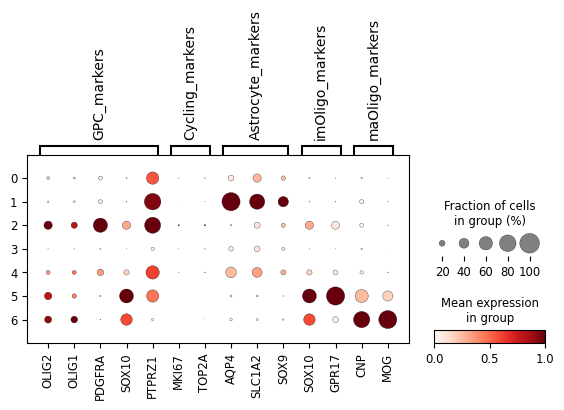

In [47]:
focused_markers = {
    # Core neuronal cell types
    # Excitatory neurons found in the cortex, inhibitory and MSN neurons found in the striatum
    "GPC_markers": ["OLIG2","OLIG1","PDGFRA","SOX10","PTPRZ1"],
    "Cycling_markers": ["MKI67","TOP2A"],
    "Astrocyte_markers": ["AQP4","SLC1A2","SOX9"],
    "imOligo_markers": ["SOX10","GPR17"],
    "maOligo_markers": ["CNP","MOG"]
}

# Filter for genes present in your dataset
filtered_markers = {
    celltype: [gene for gene in genes if gene in adata_combined_cluster2.var_names]
    for celltype, genes in focused_markers.items()
    if any(gene in adata_combined_cluster2.var_names for gene in genes)
}

# Create dotplot
sc.pl.dotplot(adata_combined_cluster2,
             filtered_markers,
             groupby='leiden_cluster2_res0_5',
             standard_scale='var')

# Let's also see which markers are missing from our dataset
for celltype, genes in focused_markers.items():
    missing = [gene for gene in genes if gene not in adata_combined_cluster2.var_names]
    if missing:
        print(f"Missing {celltype} markers: {missing}")

In [48]:
# re-name clusters
# Create the mapping dictionary
cluster_to_cell_type = {'0': 'imAstrocyte', 
                        '1': 'Astrocyte',
                        '2': 'GPC',
                        '3': 'Mouse1',
                        '4': 'Mouse2',
                        '5': 'imOL',
                        '6': 'maOL',
}

adata_combined_cluster2.obs["cell_type"] = adata_combined_cluster2.obs["leiden_cluster2_res0_5"].map(cluster_to_cell_type)

In [49]:
# save adata before moving on to next step
# Save adata object before moving on to next step
# Rename the 'cell_id' column to avoid conflict with the index
# This keeps the informative concatenated index while preserving the original cell_id data
adata_combined_cluster2.obs = adata_combined_cluster2.obs.rename(columns={'cell_id': 'cell_id_original'})

In [ ]:
adata_combined_cluster2.write_h5ad(f'{ANNDATA_DIR}/adata_combined_cluster2.h5ad')

In [50]:
# Export raw counts matrix
raw_counts_df = pd.DataFrame(
    adata_combined_cluster2.layers['raw'].toarray(),  # Convert sparse matrix to dense
    index=adata_combined_cluster2.obs_names,
    columns=adata_combined_cluster2.var_names
)
raw_counts_df.to_csv(f'{FILES_FOR_R_DIR}/raw_counts_combined_cluster2.csv')

# Export gene information
gene_info_df = adata_combined_cluster2.var.copy()
gene_info_df.to_csv(f'{FILES_FOR_R_DIR}/gene_info_combined_cluster2.csv')

In [51]:
# Export comprehensive metadata including spatial coordinates and UMAP embeddings
# Combine all observation metadata with spatial coordinates and UMAP embeddings
comprehensive_metadata = adata_combined_cluster2.obs.copy()

# Add the current cell names (index) as a column
comprehensive_metadata['current_cell_id'] = adata_combined_cluster2.obs.index

# Add spatial coordinates
comprehensive_metadata['spatial_x'] = adata_combined_cluster2.obsm['spatial'][:, 0]
comprehensive_metadata['spatial_y'] = adata_combined_cluster2.obsm['spatial'][:, 1]

# Add UMAP embeddings
comprehensive_metadata['UMAP_1'] = adata_combined_cluster2.obsm['X_umap'][:, 0]
comprehensive_metadata['UMAP_2'] = adata_combined_cluster2.obsm['X_umap'][:, 1]

# Add PCA coordinates if available
if 'X_pca' in adata_combined_cluster2.obsm:
    for i in range(min(5, adata_combined_cluster2.obsm['X_pca'].shape[1])):
        comprehensive_metadata[f'PC{i+1}'] = adata_combined_cluster2.obsm['X_pca'][:, i]

# Create output directory if it doesn't exist
output_dir = FILES_FOR_R_DIR
os.makedirs(output_dir, exist_ok=True)

# Save comprehensive metadata to CSV
output_filename = f'{output_dir}/adata_combined_cluster2_comprehensive_cell_metadata.csv'
comprehensive_metadata.to_csv(output_filename, index=False)

print(f"Comprehensive metadata exported to: {output_filename}")
print(f"Total cells: {len(comprehensive_metadata)}")
print(f"Total columns: {len(comprehensive_metadata.columns)}")
print(f"Columns included:")
print(comprehensive_metadata.columns.tolist())
print(f"\nFirst few rows:")
print(comprehensive_metadata.head())

Comprehensive metadata exported to: /Users/haichelm/Documents/Goldman_Lab/Composition_Paper/composition_analysis_github/outputs/files_for_R/adata_combined_cluster2_comprehensive_cell_metadata.csv
Total cells: 13147
Total columns: 45
Columns included:
['cell_id_original', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'annotation', 'sample_id', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_genes', 'leiden_res0_1', 'leiden_res0_5', 'leiden_res0_75', 'leiden_res1', 'composite_human_score', 'leiden_cluster2_res0_1', 'leiden_cluster2_res0_5', 'leiden_cluster2_res0_75', 'leiden_cluster2_res1', 'current_cel

### Remove clusters that still appear to be mouse, and then re-cluster only human cells

In [ ]:
# remove clusters 3 and 5 and re-cluster
adata_combined_human = adata_combined_cluster2[~adata_combined_cluster2.obs['cell_type'].isin(['Mouse1', 'Mouse2'])].copy()

In [ ]:
# make sure that those two clusters are removed, how many cells of each type?
adata_combined_human.obs['cell_type'].value_counts()

In [ ]:
# re-find variable features
# to use default seurat method:
sc.pp.highly_variable_genes(adata_combined_human, flavor = "seurat")

# Check number of genes and plot
n_genes = sum(adata_combined_human.var.highly_variable)
print(f"Number of highly variable genes: {n_genes}")
sc.pl.highly_variable_genes(adata_combined_human)

In [ ]:
# Dimensionality reduction 
sc.tl.pca(adata_combined_human)

sc.pp.neighbors(adata_combined_human)

sc.tl.umap(adata_combined_human, random_state = 42)

sc.tl.leiden(adata_combined_human, random_state = 42, key_added="leiden_human_res0_1",resolution=0.1)
sc.tl.leiden(adata_combined_human, random_state = 42, key_added="leiden_human_res0_3",resolution=0.3)
sc.tl.leiden(adata_combined_human, random_state = 42, key_added="leiden_human_res0_4",resolution=0.4)
sc.tl.leiden(adata_combined_human, random_state = 42, key_added="leiden_human_res0_5",resolution=0.5)
sc.tl.leiden(adata_combined_human, random_state = 42, key_added="leiden_human_res0_75",resolution=0.75)
sc.tl.leiden(adata_combined_human, random_state = 42, key_added="leiden_human_res1",resolution=1.0)

In [ ]:
# Plot UMAPs with different resolutions
sc.pl.umap(
    adata_combined_human,
    color=["leiden_human_res0_3", "leiden_human_res0_4", "leiden_human_res0_5", "leiden_human_res1"],
    ncols=2,
    legend_loc = "on data",
    title = ["0.3 Resolution", "0.4 Resolution", "0.5 Resolution", "0.6 Resolution", "1 Resolution"]
)

In [ ]:
# Re-assess quality control and cell filtering by visualizing other features of the data 
sc.pl.umap(
    adata_combined_human,
    color=["leiden_human_res0_4", "sample_id", "transcript_counts", "cell_type"],
    ncols=2,
    title = ["0.4 Resolution", "Sample ID", "Transcript Counts", "Previous Cell Type"]
)

0.4 resolution in new clustering reflects previous cell typing quite well

In [ ]:
# Visualize human probe specificity scores
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# UMAP colored by score
sc.pl.umap(adata_combined_human, color=['composite_human_score'], ax=ax1, show=False)
ax1.set_title('Composite Human Score on UMAP')

# UMAP colored by cluster IDs
sc.pl.umap(adata_combined_human, color=['leiden_human_res0_4'], ax=ax3, legend_loc='on data', show=False)
ax3.set_title('Cluster IDs on UMAP')

# Violin plot by cluster
sc.pl.violin(adata_combined_human, 'composite_human_score', groupby='leiden_human_res0_4', ax=ax2)
ax2.set_title('Score Distribution by Cluster')

plt.tight_layout()
plt.show()

### Visualize marker genes to confirm cell typing

In [ ]:
# Visualize marker genes for each cluster
sc.tl.rank_genes_groups(adata_combined_human, groupby='leiden_human_res0_4', method='wilcoxon', layer = 'normalized', use_raw = False)

# Create visualizations of the marker genes
# Dotplot showing top markers for each cluster
sc.pl.rank_genes_groups_dotplot(
    adata_combined_human, 
    groupby='leiden_human_res0_4', 
    n_genes=10,  # Show top 10 genes per cluster
    standard_scale='var',
    title='Top Marker Genes by Cluster (Resolution 0.4) Human Cells'
)


In [ ]:
focused_markers = {
    # Core neuronal cell types
    # Excitatory neurons found in the cortex, inhibitory and MSN neurons found in the striatum
    "GPC_markers": ["OLIG2","OLIG1","PDGFRA","SOX10","PTPRZ1"],
    "Cycling_markers": ["MKI67","TOP2A"],
    "Astrocyte_markers": ["AQP4","SLC1A2","SOX9"],
    "imOligo_markers": ["SOX10","GPR17"],
    "maOligo_markers": ["CNP","MOG"]
}

# Filter for genes present in your dataset
filtered_markers = {
    celltype: [gene for gene in genes if gene in adata_combined_human.var_names]
    for celltype, genes in focused_markers.items()
    if any(gene in adata_combined_human.var_names for gene in genes)
}

# Create dotplot
sc.pl.dotplot(adata_combined_human,
             filtered_markers,
             groupby='leiden_human_res0_4',
             standard_scale='var')

# Let's also see which markers are missing from our dataset
for celltype, genes in focused_markers.items():
    missing = [gene for gene in genes if gene not in adata_combined_human.var_names]
    if missing:
        print(f"Missing {celltype} markers: {missing}")

In [ ]:
# re-name clusters for final typing
# Create the mapping dictionary
cluster_to_cell_type = {'0': 'Astrocyte', 
                        '1': 'imAstrocyte',
                        '2': 'GPC',
                        '3': 'imOL',
                        '4': 'maOL',
}

adata_combined_human.obs["final_cell_type"] = adata_combined_human.obs["leiden_human_res0_4"].map(cluster_to_cell_type)

### Final visualizations of UMAPs, genes of interest

In [ ]:
# plot umap of final cell types
sc.pl.umap(adata_combined_human, color=['final_cell_type'], legend_loc='on data')

In [ ]:
#plot violin plot of receptors of interest

sc.pl.violin(adata_combined_human, ["CD82","CA10","ERBB3","LRP1","CCND1"], groupby='final_cell_type', layer = 'normalized', use_raw = False)

In [ ]:
# Visualize some human-specific genes (PDGFRA) on the UMAP
sc.pl.umap(
    adata_combined_human,
    color=["PDGFRA"],
    ncols=1,
    legend_loc = "on data",
    title = ["PDGFRA"],
    size = 10,
    layer = 'normalized'
)

In [ ]:
sc.pl.umap(
    adata_combined_human,
    color=["PTPRZ1"],
    ncols=1,
    legend_loc = "on data",
    title = ["PTPRZ1"],
    size = 10,
    layer = 'normalized'
)

### Export files for 'final' human cell object

In [ ]:
# Now write the adata file 
adata_combined_human.write_h5ad(f'{ANNDATA_DIR}/adata_combined_human.h5ad')

In [ ]:
# Export raw counts matrix
raw_counts_df = pd.DataFrame(
    adata_combined_human.layers['raw'].toarray(),  # Convert sparse matrix to dense
    index=adata_combined_human.obs_names,
    columns=adata_combined_human.var_names
)
raw_counts_df.to_csv(f'{FILES_FOR_R_DIR}/raw_counts_combined_human.csv')

# Export gene information
gene_info_df = adata_combined_human.var.copy()
gene_info_df.to_csv(f'{FILES_FOR_R_DIR}/gene_info_combined_human.csv')

In [ ]:
# Export comprehensive metadata including spatial coordinates and UMAP embeddings
# Combine all observation metadata with spatial coordinates and UMAP embeddings
comprehensive_metadata = adata_combined_human.obs.copy()

# Add the current cell names (index) as a column
comprehensive_metadata['current_cell_id'] = adata_combined_human.obs.index

# Add spatial coordinates
comprehensive_metadata['spatial_x'] = adata_combined_human.obsm['spatial'][:, 0]
comprehensive_metadata['spatial_y'] = adata_combined_human.obsm['spatial'][:, 1]

# Add UMAP embeddings
comprehensive_metadata['UMAP_1'] = adata_combined_human.obsm['X_umap'][:, 0]
comprehensive_metadata['UMAP_2'] = adata_combined_human.obsm['X_umap'][:, 1]

# Add PCA coordinates if available
if 'X_pca' in adata_combined_human.obsm:
    for i in range(min(5, adata_combined_human.obsm['X_pca'].shape[1])):
        comprehensive_metadata[f'PC{i+1}'] = adata_combined_human.obsm['X_pca'][:, i]

# Create output directory if it doesn't exist
output_dir = FILES_FOR_R_DIR
os.makedirs(output_dir, exist_ok=True)

# Save comprehensive metadata to CSV
output_filename = f'{output_dir}/adata_combined_human_comprehensive_cell_metadata.csv'
comprehensive_metadata.to_csv(output_filename, index=False)

print(f"Comprehensive metadata exported to: {output_filename}")
print(f"Total cells: {len(comprehensive_metadata)}")
print(f"Total columns: {len(comprehensive_metadata.columns)}")
print(f"Columns included:")
print(comprehensive_metadata.columns.tolist())
print(f"\nFirst few rows:")
print(comprehensive_metadata.head())

In [ ]:
# Export cell groups needed to visualize typing in Xenium Explorer
# Create output directory for Xenium Explorer groups
xenium_explorer_dir = XENIUM_EXPLORER_DIR
os.makedirs(xenium_explorer_dir, exist_ok=True)

# Get unique samples
samples = adata_combined_human.obs['sample_id'].unique()

# Export cell groups for each sample
for sample in samples:
    # Filter data for this sample
    sample_data = adata_combined_human[adata_combined_human.obs['sample_id'] == sample].copy()
    
    # Create cell group file for this sample
    # Format: cell_id, group (cell type), x, y coordinates
    cell_group_data = pd.DataFrame({
        'cell_id': sample_data.obs['cell_id_original'],
        'group': sample_data.obs.get('final_cell_type', sample_data.obs.get('cell_type', 'unknown')),
        'x': sample_data.obsm['spatial'][:, 0],
        'y': sample_data.obsm['spatial'][:, 1]
    })
    
    # Save to CSV
    output_filename = f'{xenium_explorer_dir}/cell_group_{sample}.csv'
    cell_group_data.to_csv(output_filename, index=False)
    
    print(f"Sample: {sample}")
    print(f"Number of cells: {len(cell_group_data)}")
    print(f"Exported to: {output_filename}")
    print(f"Cell types in this sample: {cell_group_data['group'].unique()}")
    print("-" * 50)

## Visualize spatial scatter plots

In [ ]:
# make plot of all cell types in space one sample of interest. Eventually we will want to visualize this on top of the image.
# Get unique sample IDs
sample_ids = adata_combined_human.obs['sample_id'].unique()

# Create plots for each sample
for sample_id in sample_ids:
    # Subset data for this sample
    sample_data = adata_combined_human[adata_combined_human.obs['sample_id'] == sample_id].copy()
    
    print(f"Plotting sample: {sample_id}")
    print(f"Number of cells: {len(sample_data)}")
    
    # Create spatial scatter plot
    sq.pl.spatial_scatter(
        sample_data,
        library_id="spatial",
        shape=None,
        color=["final_cell_type"],  # or whatever cell type column you want
        wspace=0.4,
        size=8,
        title=f"Sample: {sample_id}"
    )

In [ ]:
# make plot of all cell types in space one sample of interest. 

# Choose a specific sample
target_sample = "C27_33475"  # Change this to your desired sample

# Subset data for this sample
sample_data = adata_combined_human[adata_combined_human.obs['sample_id'] == target_sample].copy()

print(f"Plotting sample: {target_sample}")
print(f"Number of cells: {len(sample_data)}")

# Create spatial scatter plot
sq.pl.spatial_scatter(
    sample_data,
    library_id="spatial",
    shape=None,
    color=["final_cell_type"],
    groups=["GPC"],
    wspace=0.4,
    size=8,
    title=f"Sample: {target_sample}"
)


In [ ]:
# Configuration parameters - easily change these to explore different combinations
target_sample = "C27_33475"  # Change this to your desired sample
#target_sample = "C27_33475"  # Change this to your desired sample
target_cell_type = "GPC"  # Change this to your desired cell type
genes_of_interest = ["APP", "FGFR1", "IL1RAP", "IL6ST","ITGAV","TNFRSF21"]  # Add more genes as needed
#genes_of_interest = ["PDGFRA", "CD82", "ERBB3", "ERBB4","LRP1","LRP6"]  # Add more genes as needed


# Subset data for the target sample
sample_data = adata_combined_human[adata_combined_human.obs['sample_id'] == target_sample].copy()

# Further subset to only include the target cell type
if target_cell_type != "All":
    cell_type_data = sample_data[sample_data.obs['final_cell_type'] == target_cell_type].copy()
else:
    cell_type_data = sample_data.copy()

print(f"Plotting sample: {target_sample}")
print(f"Target cell type: {target_cell_type}")
print(f"Number of cells in sample: {len(sample_data)}")
print(f"Number of cells of target type: {len(cell_type_data)}")

# Check which genes are available in the dataset
available_genes = [gene for gene in genes_of_interest if gene in adata_combined_human.var_names]
missing_genes = [gene for gene in genes_of_interest if gene not in adata_combined_human.var_names]

print(f"Available genes: {available_genes}")
if missing_genes:
    print(f"Missing genes: {missing_genes}")

# 1. Create spatial scatter plot for cell types (showing all cell types in the sample)
sq.pl.spatial_scatter(
    sample_data,
    library_id="spatial",
    shape=None,
    color=["final_cell_type"],
    groups=[target_cell_type] if target_cell_type != "All" else None,
    wspace=0.4,
    size=8,
    title=f"Sample: {target_sample} - Cell Types"
)

# 2. Create gridded plot with all genes - ONLY in GPC cells
if available_genes:
    # Sort GPC cells by expression (highest first) for better visualization
    # Use the first gene for sorting, or you could use a composite score
    expression_values = cell_type_data[:, available_genes[0]].layers['normalized'].toarray().flatten()
    sorted_indices = np.argsort(expression_values)[::-1]
    cell_type_data_sorted = cell_type_data[sorted_indices].copy()
    
    # Print expression statistics for each gene
    print(f"\nExpression statistics in {target_cell_type} cells:")
    for gene in available_genes:
        expr_vals = cell_type_data[:, gene].layers['normalized'].toarray().flatten()
        print(f"  {gene}: range {expr_vals.min():.3f} to {expr_vals.max():.3f}, "
              f"cells with expr > 0: {(expr_vals > 0).sum()}/{len(expr_vals)}")
    
    # Create gridded plot with all genes - each with individual titles
    sq.pl.spatial_scatter(
        cell_type_data_sorted,
        library_id="spatial",
        shape=None,
        color=available_genes,  # Pass all genes at once
        wspace=0.01,
        hspace=0.2,
        size=10,
        ncols=3,  # Adjust number of columns as needed
        title=[f"{gene} in {target_cell_type}" for gene in available_genes],  # Individual titles for each gene
        layer='normalized'
    )
else:
    print("No genes of interest are available in the dataset")

In [ ]:
# Sort cells by expression level (highest first) before plotting
def plot_spatial_expression_sorted(sample_id, gene, cell_type="All", adata_obj=None):
    if adata_obj is None:
        adata_obj = adata_combined_human
    
    # Subset data
    sample_data = adata_obj[adata_obj.obs['sample_id'] == sample_id].copy()
    if cell_type != "All":
        sample_data = sample_data[sample_data.obs['final_cell_type'] == cell_type].copy()
    
    # Get expression values
    expression_values = sample_data[:, gene].layers['normalized'].toarray().flatten()
    
    # Sort by expression (highest first)
    sorted_indices = np.argsort(expression_values)[::-1]
    sample_data_sorted = sample_data[sorted_indices].copy()
    
    print(f"Expression range for {gene}: {expression_values.min():.3f} to {expression_values.max():.3f}")
    print(f"Number of cells with expression > 0: {(expression_values > 0).sum()}")
    
    # Plot with sorted data
    sq.pl.spatial_scatter(
        sample_data_sorted,
        library_id="spatial",
        shape=None,
        color=[gene],
        wspace=0.4,
        size=8,
        title=f"{sample_id} - {gene} Expression (Sorted by Expression)",
        layer='normalized'
    )

# Usage
plot_spatial_expression_sorted("WA09_GFP_44471", "PDGFRA", "GPC")